# Imports

- If your setup was done correctly, you should be able to run the following cell without any issues.

In [1]:
from hw4lib.data import (
    H4Tokenizer,
    LMDataset,
    verify_dataloader
)
from hw4lib.model import (
    CausalMask,
    PadMask,
    PositionalEncoding,
    DecoderOnlyTransformer
)
from hw4lib.utils import (
    create_optimizer,
    create_scheduler,
    plot_lr_schedule
)
from hw4lib.trainers import (
    LMTrainer,
)
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import yaml
import gc
import torch
from torchinfo import summary
import os
import json
import tarfile
import shutil
import wandb
import yaml
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "mps"
print(f"Using device: {device}")

Using device: cuda


# Experiments
From this point onwards you may want to switch to a `GPU` runtime. 
- `OBJECTIVE`: You must achieve a per-character perplexity ≤ 3.5 in order to get points for Task 2.

## Config
- You can use the `config.yaml` file to set your config for your ablation study.

---
### Notes:

- Set `tokenization: token_type:` to specify your desired tokenization strategy
- You will need to set the root path to your `hw4p1_data` folder in `data: root:`. This will depend on your setup. For eg. if you are following out setup instruction:
  - `PSC`: `"/local/hw4_data/hw4p1_data"`
  - `Colab:`: `"/content/hw4_data/hw4p1_data"`
  - `Kaggle:`: `"/kaggle/input/s25-hw4-data/hw4p1_data"`
- There's extra configurations in the `optimizer` section which will only be relevant if you decide to use the `create_optimizer` function we've provided in `hw4lib/utils/create_optimizer.py`.
- `BE CAREFUL` while setting numeric values. Eg. `1e-4` will get serialized to a `str` while `1.0e-4` gets serialized to float. 


In [ ]:
%%writefile config.yaml

Name                      : "Zian Pan"
###### Tokenization ------------------------------------------------------------
tokenization:
  token_type                : "10k"       # [char, 1k, 5k, 10k]
  token_map :
      'char': 'hw4lib/data/tokenizer_jsons/tokenizer_char.json'
      '1k'  : 'hw4lib/data/tokenizer_jsons/tokenizer_1000.json'
      '5k'  : 'hw4lib/data/tokenizer_jsons/tokenizer_5000.json'
      '10k' : 'hw4lib/data/tokenizer_jsons/tokenizer_10000.json'

###### Dataset -----------------------------------------------------------------
data:                    # Currently setup for Colab assuming out setup
  root                 : "/root/autodl-tmp/hw4_data/hw4p1_data/"  # TODO: Set the root path of your data
  train_partition      : "train"  # train
  val_partition        : "val"    # val
  test_partition       : "test"   # test
  subset               : 1.0      # Load a subset of the data (for debugging, testing, etc
  batch_size           : 64       # 128 / 256 / 64
  NUM_WORKERS          : 4        # Set to 0 for CPU

###### Network Specs -------------------------------------------------------------
model: # Decoder-Only Language Model (HW4P1)
  d_model                   : 512
  d_ff                      : 512
  num_layers                : 8
  num_heads                 : 8
  dropout                   : 0.3
  layer_drop_rate           : 0.2
  weight_tying              : True

###### Common Training Parameters ------------------------------------------------
training:
  use_wandb                   : True   # Toggle wandb logging
  wandb_run_id                : "none" # "none" or "run_id"
  resume                      : False  # Resume an existing run (run_id != 'none')
  epochs                      : 50
  gradient_accumulation_steps : 1
  wandb_project               : "hw4p1-train" # wandb project to log to
  run_name                    : "full_ds_t2" # wandb run name

###### Loss ----------------------------------------------------------------------
loss: # Just good ol' CrossEntropy
  label_smoothing: 0.2

###### Optimizer -----------------------------------------------------------------
optimizer:
  name: "adamw" # Options: sgd, adam, adamw
  lr: 3.0e-4   # Base learning rate

  # Common parameters
  weight_decay: 0.0001

  # Parameter groups
  param_groups:
    - name: self_attn
      patterns: []  # Will match all parameters containing keywords set their learning rate to 0.0001
      lr: 0.0001    # LR for self_attn
      layer_decay:
        enabled: False
        decay_rate: 0.8

    - name: ffn
      patterns: [] # Will match all parameters containing "ffn" and set their learning rate to 0.0001
      lr: 0.0001   # LR for ffn
      layer_decay:
        enabled: False
        decay_rate: 0.8

  # Layer-wise learning rates
  layer_decay:
    enabled: True
    decay_rate: 0.75

  # SGD specific parameters
  sgd:
    momentum: 0.9
    nesterov: True
    dampening: 0

  # Adam specific parameters
  adam:
    betas: [0.9, 0.999]
    eps: 1.0e-8
    amsgrad: False

  # AdamW specific parameters
  adamw:
    betas: [0.9, 0.999]
    eps: 1.0e-8
    amsgrad: False

###### Scheduler -----------------------------------------------------------------
scheduler:
  name: "reduce_lr"  # Options: reduce_lr, cosine, cosine_warm

  # ReduceLROnPlateau specific parameters
  reduce_lr:
    mode: "min"  # Options: min, max
    factor: 0.1  # Factor to reduce learning rate by
    patience: 10  # Number of epochs with no improvement after which LR will be reduced
    threshold: 0.0001  # Threshold for measuring the new optimum
    threshold_mode: "rel"  # Options: rel, abs
    cooldown: 0  # Number of epochs to wait before resuming normal operation
    min_lr: 0.0000001  # Minimum learning rate
    eps: 1.0e-8  # Minimal decay applied to lr

  # CosineAnnealingLR specific parameters
  cosine:
    T_max: 50  # Maximum number of iterations
    eta_min: 1.0e-6  # Minimum learning rate
    last_epoch: -1

  # CosineAnnealingWarmRestarts specific parameters
  cosine_warm:
    T_0: 4  # Number of iterations for the first restart
    T_mult: 4  # Factor increasing T_i after each restart
    eta_min: 0.0000001  # Minimum learning rate
    last_epoch: -1

  # Warmup parameters (can be used with any scheduler)
  warmup:
    enabled: False
    type: "linear"  # Options: linear, exponential
    epochs: 10
    start_factor: 0.001
    end_factor: 1.0


Overwriting config.yaml


In [3]:
with open('config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [4]:
run_name = config['training']['run_name']

## Tokenizer

In [5]:
Tokenizer = H4Tokenizer(
    token_map  = config['tokenization']['token_map'],
    token_type = config['tokenization']['token_type']
)

                         Tokenizer Configuration (10k)                          
--------------------------------------------------------------------------------
Vocabulary size:     10000

Special Tokens:
PAD:              0
UNK:              1
MASK:             2
SOS:              3
EOS:              4
BLANK:            5

Validation Example:
--------------------------------------------------------------------------------
Input text:  [SOS]HI DEEP LEARNERS[EOS]
Tokens:      ['[SOS]', 'H', 'I', 'ĠDEEP', 'ĠLEARN', 'ERS', '[EOS]']
Token IDs:   [3, 14, 15, 1169, 2545, 214, 4]
Decoded:     [SOS]HI DEEP LEARNERS[EOS]


## Datasets

In [6]:
train_dataset  = LMDataset(
    partition  = config['data']['train_partition'],
    config     = config['data'],
    tokenizer  = Tokenizer
)

val_dataset    = LMDataset(
    partition  = config['data']['val_partition'],
    config     = config['data'],
    tokenizer  = Tokenizer
)

test_dataset   = LMDataset(
    partition  = config['data']['test_partition'],
    config     = config['data'],
    tokenizer  = Tokenizer
)

gc.collect()

Loading transcripts for train partition...


  0%|          | 667/267178 [00:00<00:39, 6668.13it/s]

100%|██████████| 267178/267178 [00:38<00:00, 6946.68it/s]


Loading transcripts for val partition...


100%|██████████| 7031/7031 [00:01<00:00, 6389.61it/s]


Loading transcripts for test partition...


100%|██████████| 7032/7032 [00:00<00:00, 7036.57it/s]


1001

## Dataloaders

In [7]:
train_loader    = DataLoader(
    dataset     = train_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = True,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = train_dataset.collate_fn
)

val_loader      = DataLoader(
    dataset     = val_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = False,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = val_dataset.collate_fn
)

test_loader     = DataLoader(
    dataset     = test_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = False,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = test_dataset.collate_fn
)

### Dataloader Verification

In [8]:
verify_dataloader(train_loader)

             Dataloader Verification              
Dataloader Partition     : train
--------------------------------------------------
Number of Batches        : 4175
Batch Size               : 64
--------------------------------------------------
Checking shapes of the data...                    



Shifted Transcript Shape : [64, 77]
Golden Transcript Shape  : [64, 77]
Transcript Lengths Shape : [64]
--------------------------------------------------
Max Transcript Length    : 105
Avg. Chars per Token     : 4.62


In [9]:
verify_dataloader(val_loader)

             Dataloader Verification              
Dataloader Partition     : val
--------------------------------------------------
Number of Batches        : 110
Batch Size               : 64
--------------------------------------------------
Checking shapes of the data...                    

Shifted Transcript Shape : [64, 80]
Golden Transcript Shape  : [64, 80]
Transcript Lengths Shape : [64]
--------------------------------------------------
Max Transcript Length    : 87
Avg. Chars per Token     : 4.61


In [10]:
verify_dataloader(test_loader)

             Dataloader Verification              
Dataloader Partition     : test
--------------------------------------------------
Number of Batches        : 110
Batch Size               : 64
--------------------------------------------------
Checking shapes of the data...                    

Shifted Transcript Shape : [64, 72]
Golden Transcript Shape  : [64, 72]
Transcript Lengths Shape : [64]
--------------------------------------------------
Max Transcript Length    : 86
Avg. Chars per Token     : 4.61


## Calculate Max Transcript Length




Calculating the maximum transcript length across your dataset is a crucial step when working with certain transformer models.
-  We'll use sinusoidal positional encodings that must be precomputed up to a fixed maximum length.
- This maximum length is a hyperparameter that determines:
  - How long of a sequence your model can process
  - The size of your positional encoding matrix
  - Memory requirements during training and inference
- `Requirements`: For this assignment, ensure your positional encodings can accommodate at least the longest sequence in your dataset to prevent truncation. However, you can set this value higher if you anticipate using your language model to work with longer sequences in future tasks (hint: this might be useful for P2! 😉).

In [11]:
max_transcript_length = max(train_dataset.text_max_len, val_dataset.text_max_len, test_dataset.text_max_len)
print("="*50)
print(f"{'Global Max Transcript Length':<30} : {max_transcript_length}")
print("="*50)

Global Max Transcript Length   : 105


## Model

In [12]:
model_config = config['model']
model_config.update({
    'max_len': max_transcript_length,
    'num_classes': Tokenizer.vocab_size
})
model = DecoderOnlyTransformer(**model_config)

# Get some inputs from the text loader
for batch in train_loader:
    shifted_transcripts, golden_transcripts, transcript_lengths = batch
    print("Shape of shifted_transcripts : ", shifted_transcripts.shape)
    print("Shape of golden_transcripts  : ", golden_transcripts.shape)
    print("Shape of transcript_lengths  : ", transcript_lengths.shape)
    break

model_stats = summary(model, input_data=[shifted_transcripts, transcript_lengths])
print(model_stats)

Shape of shifted_transcripts :  torch.Size([64, 69])
Shape of golden_transcripts  :  torch.Size([64, 69])
Shape of transcript_lengths  :  torch.Size([64])


Layer (type:depth-idx)                   Output Shape              Param #
DecoderOnlyTransformer                   [64, 69, 10000]           --
├─Embedding: 1-1                         [64, 69, 256]             2,560,000
├─PositionalEncoding: 1-2                [64, 69, 256]             --
├─Dropout: 1-3                           [64, 69, 256]             --
├─LayerNorm: 1-4                         [64, 69, 256]             512
├─Linear: 1-5                            [64, 69, 10000]           2,570,000
Total params: 5,130,512
Trainable params: 5,130,512
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 328.35
Input size (MB): 0.04
Forward/backward pass size (MB): 371.37
Params size (MB): 20.52
Estimated Total Size (MB): 391.93


## Wandb

In [13]:
wandb.login(key="8475199febe13b3465c7d5e4a595bba7422c14fc")

wandb: Currently logged in as: zianp (zianp-personal). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

## Trainer

Every time you run the trainer, it will create a new directory in the `expts` folder with the following structure:
```
expts/
    └── {run_name}/
        ├── config.yaml
        ├── model_arch.txt
        ├── checkpoints/
        │   ├── checkpoint-best-metric-model.pth
        │   └── checkpoint-last-epoch-model.pth
        ├── attn/
        │   └── {attention visualizations}
        └── text/
            └── {generated text outputs}
```

In [14]:
model = model.to(device)

In [15]:
trainer = LMTrainer(
    model=model,
    tokenizer=Tokenizer,
    config=config,
    run_name=run_name,
    config_file="config.yaml",
    device=device
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Using device: cuda


/root/hw4/dl-hw4/hw4lib/trainers/lm_trainer.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


### Setup Optimizer and Scheduler

You can set your own optimizer and scheduler by setting the class members in the `LMTrainer` class.
Eg:
```python
trainer.optimizer = optim.AdamW(model.parameters(), lr=config['optimizer']['lr'], weight_decay=config['optimizer']['weight_decay'])
trainer.scheduler = optim.lr_scheduler.CosineAnnealingLR(trainer.optimizer, T_max=config['training']['epochs'])
```

We also provide a utility function to create your own optimizer and scheduler with the congig and some extra bells and whistles. You are free to use it or not. Do read their code and documentation to understand how it works (`hw4lib/utils/*`).


#### Setting up the optimizer

In [16]:
trainer.optimizer = create_optimizer(
    model=model,
    opt_config=config['optimizer']
)


🔧 Configuring Optimizer:
├── Type: ADAMW
├── Base LR: 0.0003
├── Weight Decay: 0.0001
├── Parameter Groups:
│   ├── Group: self_attn
│   │   ├── LR: 0.0001
│   │   └── Patterns: []
│   ├── Group: ffn
│   │   ├── LR: 0.0001
│   │   └── Patterns: []
│   └── Default Group (unmatched parameters)
└── AdamW Specific:
    ├── Betas: [0.9, 0.999]
    ├── Epsilon: 1e-08
    └── AMSGrad: False


#### Creating a test scheduler and plotting the learning rate schedule


📈 Configuring Learning Rate Scheduler:
├── Type: REDUCE_LR
├── ReduceLROnPlateau Settings:
│   ├── Mode: min
│   ├── Factor: 0.1
│   ├── Patience: 10 epochs
│   ├── Threshold: 0.0001
│   ├── Threshold Mode: rel
│   ├── Cooldown: 0 epochs
│   └── Min LR: 1e-07


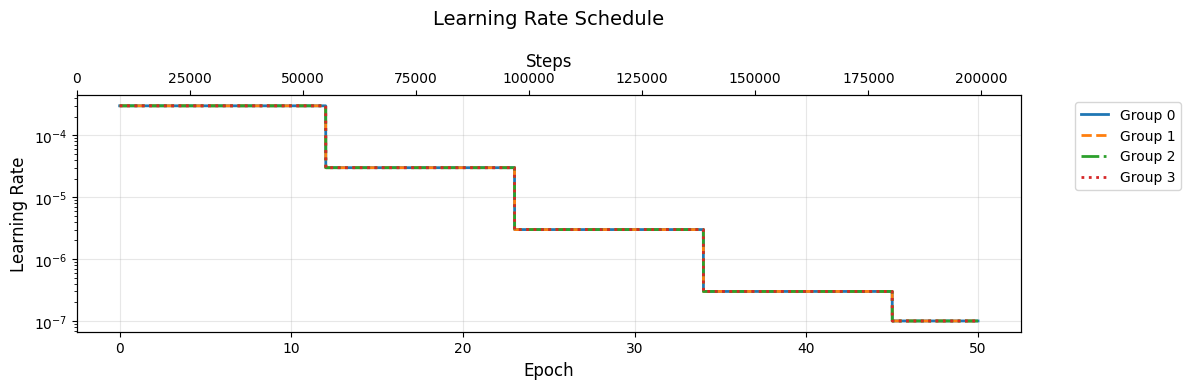

In [17]:
test_scheduler = create_scheduler(
    optimizer=trainer.optimizer,
    scheduler_config=config['scheduler'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)

plot_lr_schedule(
    scheduler=test_scheduler,
    num_epochs=config['training']['epochs'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)

#### Setting up the scheduler

In [18]:
trainer.scheduler = create_scheduler(
    optimizer=trainer.optimizer,
    scheduler_config=config['scheduler'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)


📈 Configuring Learning Rate Scheduler:
├── Type: REDUCE_LR
├── ReduceLROnPlateau Settings:
│   ├── Mode: min
│   ├── Factor: 0.1
│   ├── Patience: 10 epochs
│   ├── Threshold: 0.0001
│   ├── Threshold Mode: rel
│   ├── Cooldown: 0 epochs
│   └── Min LR: 1e-07


# Train
- Set your epochs

In [ ]:
trainer.train(train_loader, val_loader, epochs=config['training']['epochs'])

[Training LM]:   0%|          | 0/4175 [00:00<?, ?it/s]

Generating with greedy search...

📊 Metrics (Epoch 0):
├── TRAIN:
│   ├── ce_loss_char: 1.6482
│   ├── ce_loss_token: 7.6087
│   ├── perplexity_char: 5.1978
│   └── perplexity_token: 2015.6998
└── VAL:
    ├── ce_loss_char: 1.6335
    ├── ce_loss_token: 7.5372
    ├── perplexity_char: 5.1219
    └── perplexity_token: 1876.6532
└── TRAINING:
    └── learning_rate: 0.000300


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


Generating with greedy search...

📊 Metrics (Epoch 1):
├── TRAIN:
│   ├── ce_loss_char: 1.6243
│   ├── ce_loss_token: 7.4982
│   ├── perplexity_char: 5.0748
│   └── perplexity_token: 1804.7848
└── VAL:
    ├── ce_loss_char: 1.6168
    ├── ce_loss_token: 7.4603
    ├── perplexity_char: 5.0372
    └── perplexity_token: 1737.7040
└── TRAINING:
    └── learning_rate: 0.000300


[Training LM]:   2%|▏         | 90/4175 [00:03<02:39, 25.69it/s, acc_step=1/1, ce_loss_token=7.4660, perplexity_token=1747.5566]

# Evaluate


In [ ]:
test_metrics, test_generation_results = trainer.evaluate(test_loader)
# Cleanup
trainer.cleanup()


📊 Metrics (Epoch 50):
└── TEST:
    ├── ce_loss_char: 1.9285
    ├── ce_loss_token: 8.0409
    ├── perplexity_char: 6.8794
    └── perplexity_token: 3105.4341
└── TRAINING:
    └── learning_rate: 0.000030
Generating with greedy search...
Generating with beam search...
Could not generate results for beam: 
Generating with sampling...
Could not generate results for sample: 


learning_rate,███████████████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁
test/ce_loss_char,▁
test/ce_loss_token,▁
test/perplexity_char,▁
test/perplexity_token,▁
train/ce_loss_char,█▇▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/ce_loss_token,█▇▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/perplexity_char,█▇▇▆▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/perplexity_token,█▇▆▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/ce_loss_char,█▇▇▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/ce_loss_token,█▇▇▅▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


# Submission
To submit your assignment, you will need to create a `handin.tar` with the following directory structure:

```
handin/
├── mytorch/                     # Your implemented modules
├── test_metrics.json            # Results from evaluation
├── test_generated_results.json  # Sample text generations
└── model_arch.txt               # Model architecture summary
```

- Simply run the cell below once you are satisfied with your current state and this will create the `handin.tar` file.
- After running the above cell, you should see the handin.tar file in the current directory
- Upload the `handin.tar` file to the `HW4P1` assignment on Autolab.

In [ ]:
# Create temporary handin directory
if os.path.exists('handin'):
    shutil.rmtree('handin')
os.makedirs('handin')

# Copy mytorch directory
shutil.copytree('mytorch', 'handin/mytorch')

# Save final results
with open('handin/test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=4)

with open('handin/test_generated_results.json', 'w') as f:
    json.dump(test_generation_results['greedy'], f, indent=4)

# Save model architecture
with open('handin/model_arch.txt', 'w') as f:
    f.write(str(model_stats))

# Create tar file with all exclusions handled by filter
with tarfile.open('handin.tar', 'w') as tar:
    def filter_files(tarinfo):
        # Skip unwanted files
        if any(pattern in tarinfo.name for pattern in [
            '.DS_Store',
            '__pycache__',
            '.pyc'
        ]):
            return None
        return tarinfo

    tar.add('handin', arcname='handin', filter=filter_files)

# Cleanup
shutil.rmtree('handin')

print("Created handin.tar successfully!")

## After running the above cell, you should see the handin.tar file in the current directory
!ls

Created handin.tar successfully!
'HW4P1_nb _sim.ipynb'   config.yaml   hw4_data_subset   requirements.txt
 HW4P1_nb.ipynb         expts	      hw4lib	        tests
 README.md	        handin.tar    mytorch	        wandb
